## CSC 580 AI II (Winter 2026) **HW\#5 RLHF** -- Start-up code

### **Simple_RLHF.ipynb** -- Simple implementation of Reinforcement Learning Human Feedback (RLHF)

### Students fill in the places indicated with "(*) TODO" (1-12). Sample outputs are baked in this notebook file but also in the html of this file

In [ ]:
## Code piece to mount my Google Drive
from google.colab import drive
drive.mount("/content/drive") # my Google Drive root directory will be mapped here

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Change the working directory to your own work directory (where the code file is).
import os
thisdir = '/content/drive/My Drive/CSC580_Winter2026/hw5_rlhf'
os.chdir(thisdir)

# Ensure the files are there (in the folder)
!pwd

/content/drive/My Drive/CSC580_Winter2026/RLHF


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification


In [ ]:
# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "distilgpt2"  # Smaller, faster model, https://huggingface.co/distilbert/distilgpt2
MAX_LENGTH = 256
BATCH_SIZE = 8

print(f"Device: {device}")
print(f"Model: {MODEL_NAME}")

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # load from HuggingFace
tokenizer.pad_token = tokenizer.eos_token

Device: cuda
Model: distilgpt2


## Part 1: Supervised Fine-Tuning (SFT) of Policy Model


In [ ]:
# %%
class SFTDataset:
    def __init__(self, sample_size=10000):
        print("Loading SFT dataset...")
        # Use a reasonable-sized instruction dataset
        dataset = load_dataset("databricks/databricks-dolly-15k", split="train")

        # Limit to sample_size
        sample_size = min(sample_size, len(dataset))
        dataset = dataset.select(range(sample_size))

        # Format for instruction following
        def format_example(example):
            return {
                'text': f"Instruction: {example['instruction']}\nContext: {example['context']}\nResponse: {example['response']}"
            }

        self.dataset = dataset.map(format_example, remove_columns=['instruction', 'context', 'response', 'category'])
        print(f"SFT dataset size: {len(self.dataset)}")

    def get_batch(self, batch_size=BATCH_SIZE):
        """Get batch for SFT training"""
        indices = np.random.choice(len(self.dataset), batch_size, replace=False)
        texts = [self.dataset[int(i)]['text'] for i in indices]

        # Tokenize
        tokens = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        return tokens

In [ ]:
# Function for sft training
def train_sft(num_steps=200):
    """Simple SFT training"""
    print("\n" + "="*50)
    print("STEP 1: SUPERVISED FINE-TUNING")
    print("="*50)

    # Load model -- CausalLM model (thus language modelling)
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
    model = model.to(device)

    # Ensure pad token is set for SFT model config
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    # Dataset
    dataset = SFTDataset(sample_size=5000)

    # (*) TODO 1: Create an optimizer for the model
    # Use AdamW Optimizer with learning rate 2e-5
    optimizer = None # Fill in your code

    # Training loop
    model.train()
    losses = []

    for step in range(num_steps):
        batch = dataset.get_batch(batch_size=BATCH_SIZE)
        batch = {k: v.to(device) for k, v in batch.items()}

        # Forward pass -- pass inputs and labels
        outputs = model(**batch, labels=batch['input_ids'])
        loss = outputs.loss

        # (*) TODO 2: Backward pass
        # Fill in your code
        #


        # Keep track of the losses
        losses.append(loss.item())

        if step % 50 == 0:
            print(f"  Step {step}/{num_steps}: Loss={loss.item():.4f}")

    print("SFT training complete!")

    # Save the model
    model.save_pretrained("./sft_model")
    tokenizer.save_pretrained("./sft_model")

    return model

# Train SFT model
sft_model = train_sft()



STEP 1: SUPERVISED FINE-TUNING


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading SFT dataset...
SFT dataset size: 5000


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Step 0/200: Loss=6.6811
  Step 50/200: Loss=2.2618
  Step 100/200: Loss=1.2885
  Step 150/200: Loss=1.4320
SFT training complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Part 2: Preference Dataset for Reward Modeling

In [ ]:
# %%
class PreferenceDataset:
    def __init__(self, sample_size=10000):
        print("\nLoading preference dataset...")
        # Use Anthropic HH-RLHF dataset
        dataset = load_dataset("Anthropic/hh-rlhf", split="train")

        # Limit to sample_size
        sample_size = min(sample_size, len(dataset))
        dataset = dataset.select(range(sample_size))

        # Process examples
        processed_data = []
        for example in dataset:
            chosen = example['chosen']
            rejected = example['rejected']

            # (*) TODO 3: Extract assistant responses (last part after "Assistant: ")
            # The format is: [human message]\n\nAssistant: [response]
            if "\n\nAssistant: " in chosen:
                chosen_response = # chosen.split("?????")[?????] # Get the response partchosen.split("\n\nAssistant: ")[-1]
                rejected_response = # rejected.split("?????")[?????] # Same for rejected

                # Extract prompt (everything before assistant response)
                prompt = #chosen.split("?????")[?????]  # Get the prompt part


                if len(chosen_response) > 10 and len(rejected_response) > 10:
                    processed_data.append({
                        'prompt': prompt,
                        'chosen': chosen_response,
                        'rejected': rejected_response
                    })

        self.data = processed_data
        print(f"Preference dataset size: {len(self.data)}")

    def get_batch(self, batch_size=BATCH_SIZE):
        """Get batch of (prompt, chosen, rejected)"""
        indices = np.random.choice(len(self.data), batch_size, replace=False)
        batch = [self.data[int(i)] for i in indices]

        # Tokenize
        prompts = [item['prompt'] for item in batch]
        chosen_texts = [item['chosen'] for item in batch]
        rejected_texts = [item['rejected'] for item in batch]

        # Tokenize prompts
        prompt_tokens = tokenizer(
            prompts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH // 2,
            return_tensors="pt"
        )

        # Tokenize responses
        chosen_tokens = tokenizer(
            chosen_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH // 2,
            return_tensors="pt"
        )

        rejected_tokens = tokenizer(
            rejected_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH // 2,
            return_tensors="pt"
        )

        return prompt_tokens, chosen_tokens, rejected_tokens

# Create dataset
pref_dataset = PreferenceDataset(sample_size=8000)


Loading preference dataset...
Preference dataset size: 7731


## Part 3: Reward Model Training

In [ ]:
# %%
class RewardModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Start from the pretrained model from HuggingFace (with classification head)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=1
        )

        # Ensure pad token is set
        if self.model.config.pad_token_id is None:
            self.model.config.pad_token_id = tokenizer.pad_token_id

    def forward(self, input_ids, attention_mask):
        return self.model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits.squeeze(-1)

    def compute_loss(self, chosen, rejected):
        chosen_rewards = self.forward(chosen['input_ids'], chosen['attention_mask'])
        rejected_rewards = self.forward(rejected['input_ids'], rejected['attention_mask'])

        # (*) TODO 4: Implement the Bradley-Terry loss
        # The loss should encourage chosen_rewards > rejected_rewards
        # Use log sigmoid of the difference
        diff = # Fill in your code

        # Compute the Bradley-Terry loss
        loss = -F.logsigmoid(diff).mean() # mean over minibatch

        # (*) TODO 5: accuracy is when diff is > 0 (and the mean over the list)
        accuracy = # Fill in your code

        return loss, accuracy

#--------------------
def train_reward_model(train_fraction=1.0, name="Model"):
    """Train reward model with different quality levels"""
    model = RewardModel().to(device)

    # (*) TODO 6: Create an optimizer for the reward model
    # Use Adam with learning rate 1e-5
    optimizer = # Fill in your code

    print(f"\nTraining {name} reward model...")

    model.train()
    steps = int(100 * train_fraction)  # Adjust steps based on quality

    for step in range(steps):
        _, chosen, rejected = pref_dataset.get_batch(batch_size=BATCH_SIZE)

        # Move to device
        chosen = {k: v.to(device) for k, v in chosen.items()}
        rejected = {k: v.to(device) for k, v in rejected.items()}

        # (*) TODO 7: Compute the loss using the reward model's compute_loss method
        loss, accuracy = # Fill in your code

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 20 == 0:
            print(f"  Step {step}/{steps}: Loss={loss.item():.4f}")

    print("Reward model training complete!")
    model.eval()
    return model

#--------------------
print("\n" + "="*50)
print("STEP 2: REWARD MODEL TRAINING")
print("="*50)

#-----------------------------------------------
# Train two reward models with different quality
#-----------------------------------------------
poor_rm = train_reward_model(train_fraction=0.3, name="POOR")
good_rm = train_reward_model(train_fraction=1.0, name="GOOD")


STEP 2: REWARD MODEL TRAINING


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training POOR reward model...
  Step 0/30: Loss=0.6641
  Step 20/30: Loss=0.9567
Reward model training complete!


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training GOOD reward model...
  Step 0/100: Loss=0.8713
  Step 20/100: Loss=0.8464
  Step 40/100: Loss=0.5984
  Step 60/100: Loss=0.7287
  Step 80/100: Loss=0.6444
Reward model training complete!


## 3.1 Evaluate reward models

In [ ]:
#
def evaluate_rm(model, num_batches=20):
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for _ in range(num_batches):
            _, chosen, rejected = pref_dataset.get_batch(batch_size=8)

            chosen = {k: v.to(device) for k, v in chosen.items()}
            rejected = {k: v.to(device) for k, v in rejected.items()}

            chosen_rewards = model(chosen['input_ids'], chosen['attention_mask'])
            rejected_rewards = model(rejected['input_ids'], rejected['attention_mask'])

            # (*) TODO 8: Count how many times chosen_rewards > rejected_rewards
            # This is the accuracy metric
            correct = # Fill in your code

            total_correct += correct
            total_samples += len(chosen_rewards)

    return total_correct / total_samples

poor_acc = evaluate_rm(poor_rm)
good_acc = evaluate_rm(good_rm)

print(f"\nReward Model Evaluation:")
print(f"  Poor RM Accuracy: {poor_acc:.4f}")
print(f"  Good RM Accuracy: {good_acc:.4f}")


Reward Model Evaluation:
  Poor RM Accuracy: 0.6125
  Good RM Accuracy: 0.5437


## Part 4: PPO Implementation

In [ ]:
# %%
class SimplePPO:
    def __init__(self, reward_model):
        # Start from the Policy model fine-tuned earlier
        self.policy = AutoModelForCausalLM.from_pretrained("./sft_model").to(device)
        self.reward_model = reward_model
        # reference model as the base model
        self.ref_model = AutoModelForCausalLM.from_pretrained("./sft_model").to(device)

        # Ensure pad token is set for policy and ref_model configs
        if self.policy.config.pad_token_id is None:
            self.policy.config.pad_token_id = tokenizer.pad_token_id
        if self.ref_model.config.pad_token_id is None:
            self.ref_model.config.pad_token_id = tokenizer.pad_token_id

        # (*) TODO 9: Freeze the reference model parameters
        for param in self.ref_model.parameters():
            param.requires_grad = # Fill in your code

        # (*) TODO 10: Create an optimizer for the policy model
        # Use Adam with learning rate 5e-6
        self.optimizer = # Fill in your code

        self.rewards_history = []
        self.kl_history = []
        self.episode_rewards = []  # For tracking per-episode rewards
        self.episode_kls = []      # For tracking per-episode KL divergences

    def generate_response(self, prompt, max_tokens=64):
        """Generate response with log probabilities"""
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = self.policy.generate(
                **inputs,
                max_new_tokens=max_tokens,
                do_sample=True,
                temperature=0.7,
                return_dict_in_generate=True,
                output_scores=True,
                pad_token_id=tokenizer.pad_token_id # Explicitly set pad_token_id
            )

        response_ids = outputs.sequences

        # Get log probabilities (simplified)
        if outputs.scores:
            logits = outputs.scores[-1]  # Last token only (simplified)
            log_probs = F.log_softmax(logits, dim=-1)
        else:
            log_probs = None

        return response_ids, log_probs

    def compute_reward(self, response_ids):
        """Get reward from reward model"""
        attention_mask = torch.ones_like(response_ids)
        reward = self.reward_model(response_ids, attention_mask).mean()
        return reward

    def compute_kl(self, response_ids):
        """Compute KL divergence between policy and reference"""
        attention_mask = torch.ones_like(response_ids)

        with torch.no_grad():
            # Ensure use_cache=False and return_dict=True to prevent AttributeError
            ref_outputs = self.ref_model(input_ids=response_ids, attention_mask=attention_mask, use_cache=False, return_dict=True)
            ref_logits = ref_outputs.logits

        # Ensure use_cache=False and return_dict=True to prevent AttributeError
        policy_outputs = self.policy(input_ids=response_ids, attention_mask=attention_mask, use_cache=False, return_dict=True)
        policy_logits = policy_outputs.logits

        # Simplified KL calculation
        kl = F.kl_div(
            F.log_softmax(policy_logits[:, :-1], dim=-1),
            F.softmax(ref_logits[:, :-1], dim=-1),
            reduction='batchmean'
        )

        return kl

    def train_step(self, prompt, kl_weight=0.01):
        """Single PPO step (simplified)"""
        self.policy.train()

        # Generate response
        response_ids, _ = self.generate_response(prompt)

        # Compute reward
        reward = self.compute_reward(response_ids)

        # Compute KL penalty
        kl_penalty = self.compute_kl(response_ids)

        # (*) TODO 12: Compute the PPO loss
        # We want to maximize reward but minimize KL divergence
        loss = ????? * reward + kl_weight * kl_penalty # Fill in ?????

        # Update
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
        self.optimizer.step()

        return reward.item(), kl_penalty.item()

    def train(self, prompts, num_episodes=80):
        """Training loop. Improved version with multiple prompts per episode and better tracking"""
        print(f"\nTraining PPO with {'POOR' if self.reward_model == poor_rm else 'GOOD'} reward model...")

        # Clear history
        self.rewards_history = []
        self.kl_history = []
        self.episode_rewards = []
        self.episode_kls = []

        for episode in range(num_episodes):
            # Sample multiple prompts per episode for better training
            num_prompts_per_episode = 3  # Multiple prompts per episode
            batch_rewards = []
            batch_kls = []

            for _ in range(num_prompts_per_episode):
                # Smart prompt sampling
                if episode < len(prompts):
                    # Early: go through prompts systematically
                    prompt_idx = episode % len(prompts)
                    prompt = prompts[prompt_idx]
                else:
                    # Later: random sampling
                    prompt = np.random.choice(prompts)

                reward, kl = self.train_step(prompt)
                batch_rewards.append(reward)
                batch_kls.append(kl)

            # Average over batch
            avg_reward = np.mean(batch_rewards)
            avg_kl = np.mean(batch_kls)

            # Track metrics
            self.episode_rewards.append(avg_reward)
            self.episode_kls.append(avg_kl)
            self.rewards_history.append(avg_reward)
            self.kl_history.append(avg_kl)

            # Logging
            if (episode + 1) % 20 == 0:
                # Compute moving averages
                recent_rewards = self.episode_rewards[-20:] if len(self.episode_rewards) >= 20 else self.episode_rewards
                recent_kls = self.episode_kls[-20:] if len(self.episode_kls) >= 20 else self.episode_kls

                avg_recent_reward = np.mean(recent_rewards)
                avg_recent_kl = np.mean(recent_kls)

                print(f"  Episode {episode+1}/{num_episodes}: "
                      f"Reward={avg_reward:.4f} (Avg20={avg_recent_reward:.4f}), "
                      f"KL={avg_kl:.4f} (Avg20={avg_recent_kl:.4f})")

        return self.episode_rewards, self.episode_kls


## Part 5: Training Prompts

In [ ]:
# Load training prompts
import ppo_train_prompts
from ppo_train_prompts import training_prompts

print(f"Number of training prompts: {len(training_prompts)}")

Number of training prompts: 210


In [ ]:
# Optional: Data augmentation for prompts
def augment_prompts(base_prompts, num_variations=2):
    """Create variations of prompts for more robust training"""
    augmented = []
    for prompt in base_prompts:
        augmented.append(prompt)
        # Add variations if the prompt ends with colon
        if prompt.endswith(":"):
            base = prompt.rstrip(": ")
            # Add different phrasings
            variations = [
                f"{base} Please explain in detail:",
                f"{base} Can you describe this concept?",
                f"{base} What are the key points?",
                f"{base} I'd like to understand this better:",
                f"{base} Could you elaborate on this topic?",
            ]
            # Add a couple of variations per prompt
            for i in range(min(num_variations, len(variations))):
                augmented.append(variations[i])

    # Remove any duplicates and shuffle
    augmented = list(set(augmented))
    np.random.shuffle(augmented)
    return augmented

# Use augmented prompts for even more robust training
augmented_prompts = augment_prompts(training_prompts, num_variations=2)
print(f"Total prompts with augmentation: {len(augmented_prompts)}")


Total prompts with augmentation: 468


## Part 6: Train PPO with Both Reward Models

In [ ]:
# %%
print("\n" + "="*60)
print("STEP 3: PPO TRAINING (with enhanced prompts)")
print("="*60)

# Use augmented prompts for training
ppo_training_prompts = augmented_prompts  # You can switch back to training_prompts if needed

print("\n1. Training with POOR reward model...")
ppo_poor = SimplePPO(poor_rm)
poor_rewards, poor_kls = ppo_poor.train(ppo_training_prompts, num_episodes=150)

print("\n2. Training with GOOD reward model...")
ppo_good = SimplePPO(good_rm)
good_rewards, good_kls = ppo_good.train(ppo_training_prompts, num_episodes=150)


STEP 3: PPO TRAINING (with enhanced prompts)

1. Training with POOR reward model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


Training PPO with POOR reward model...
  Episode 20/150: Reward=2.2757 (Avg20=3.7927), KL=5.9861 (Avg20=9.8607)
  Episode 40/150: Reward=1.8701 (Avg20=3.9266), KL=3.9501 (Avg20=6.3304)
  Episode 60/150: Reward=4.0104 (Avg20=3.0193), KL=6.4163 (Avg20=5.7943)
  Episode 80/150: Reward=7.1686 (Avg20=3.8656), KL=7.4657 (Avg20=6.6349)
  Episode 100/150: Reward=3.0401 (Avg20=3.5877), KL=4.8766 (Avg20=5.9807)
  Episode 120/150: Reward=2.0083 (Avg20=3.8270), KL=8.3138 (Avg20=6.9267)
  Episode 140/150: Reward=4.4056 (Avg20=3.0088), KL=3.2493 (Avg20=5.6327)

2. Training with GOOD reward model...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


Training PPO with GOOD reward model...
  Episode 20/150: Reward=-1.7180 (Avg20=-3.2671), KL=11.3277 (Avg20=7.6227)
  Episode 40/150: Reward=-3.0126 (Avg20=-3.5784), KL=8.7511 (Avg20=6.6706)
  Episode 60/150: Reward=-4.6594 (Avg20=-3.0084), KL=8.1304 (Avg20=5.6561)
  Episode 80/150: Reward=-4.5526 (Avg20=-3.6313), KL=8.6507 (Avg20=6.3747)
  Episode 100/150: Reward=-4.7588 (Avg20=-3.3761), KL=8.4270 (Avg20=6.7468)
  Episode 120/150: Reward=-0.2292 (Avg20=-3.1362), KL=3.7200 (Avg20=5.9865)
  Episode 140/150: Reward=-2.8102 (Avg20=-3.0483), KL=3.3449 (Avg20=5.5744)


## Part 7: Evaluation and Comparison

In [ ]:
from ppo_train_prompts import evaluation_prompts

def augment_evaluation_prompts(prompts):
    """Create diverse evaluation prompts"""
    augmented = []
    for prompt in prompts:
        augmented.append(prompt)
        # Add variations
        if ":" in prompt:
            base = prompt.rstrip(": ")
            # Different questioning styles
            styles = [
                f"Please provide a comprehensive answer to: {base}",
                f"I need a detailed explanation of: {base}",
                f"Can you analyze and discuss: {base}",
                f"Provide insights about: {base}",
                f"Explain with examples: {base}",
            ]
            # Add a couple of variations
            augmented.extend(styles[:2])
    return list(set(augmented))

augmented_evaluation_prompts = augment_evaluation_prompts(evaluation_prompts)
print(f"Total evaluation prompts with augmentation: {len(augmented_evaluation_prompts)}")

Total evaluation prompts with augmentation: 88


In [ ]:
def evaluate_policy(policy, reward_model, eval_prompts, num_prompts=30):
    """Evaluate policy using reward model"""
    policy.eval()
    rewards = []

    # choose evaluation prompts if num_prompts is given
    if num_prompts < len(eval_prompts):
      eval_indices = np.random.choice(len(eval_prompts), min(num_prompts, len(eval_prompts)), replace=False)
      eval_prompts = [eval_prompts[i] for i in eval_indices]

    with torch.no_grad():
        for prompt in eval_prompts:
            inputs = tokenizer(prompt, return_tensors="pt").to(device)

            output = policy.generate(
                **inputs,
                max_new_tokens=128,
                do_sample=True,
                temperature=0.7,
                pad_token_id=tokenizer.pad_token_id # Explicitly set pad_token_id to suppress warning
            )

            reward = reward_model(output, torch.ones_like(output)).mean().item()
            rewards.append(reward)

    policy.train()
    return np.mean(rewards), np.std(rewards), rewards

print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

#-------------------------------
# Load models for comparison
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
# Ensure pad_token_id is set for base_model config
if base_model.config.pad_token_id is None:
    base_model.config.pad_token_id = tokenizer.pad_token_id

sft_model_eval = AutoModelForCausalLM.from_pretrained("./sft_model").to(device)
# Ensure pad_token_id is set for sft_model_eval config
if sft_model_eval.config.pad_token_id is None:
    sft_model_eval.config.pad_token_id = tokenizer.pad_token_id

# Evaluate all models using GOOD reward model
print("\nEvaluating models (using GOOD RM as judge):")

# Evaluation using all augment prompts
eval_prompts = augmented_evaluation_prompts
base_reward, base_std, base_all_rewards = evaluate_policy(base_model, good_rm, eval_prompts)
sft_reward, sft_std, sft_all_rewards = evaluate_policy(sft_model_eval, good_rm, eval_prompts)
poor_reward, poor_std, poor_all_rewards = evaluate_policy(ppo_poor.policy, good_rm, eval_prompts)
good_reward, good_std, good_all_rewards = evaluate_policy(ppo_good.policy, good_rm, eval_prompts)

print(f"\nResults (mean \u00b1 std):")
print(f"  Base Model:       {base_reward:.4f} \u00b1 {base_std:.4f}")
print(f"  SFT Model:        {sft_reward:.4f} \u00b1 {sft_std:.4f}")
print(f"  Poor RM Policy:   {poor_reward:.4f} \u00b1 {poor_std:.4f}")
print(f"  Good RM Policy:   {good_reward:.4f} \u00b1 {good_std:.4f}")

print(f"\nImprovement over Base:")
print(f"  SFT Model:        {((sft_reward - base_reward) / abs(base_reward) * 100):.1f}%")
print(f"  Poor RM Policy:   {((poor_reward - base_reward) / abs(base_reward) * 100):.1f}%")
print(f"  Good RM Policy:   {((good_reward - base_reward) / abs(base_reward) * 100):.1f}%")


FINAL EVALUATION


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


Evaluating models (using GOOD RM as judge):

Results (mean ± std):
  Base Model:       -1.7317 ± 2.5260
  SFT Model:        -3.2405 ± 2.1337
  Poor RM Policy:   -2.5088 ± 2.3733
  Good RM Policy:   -2.3719 ± 2.3686

Improvement over Base:
  SFT Model:        -87.1%
  Poor RM Policy:   -44.9%
  Good RM Policy:   -37.0%


## Part 8: Visualization

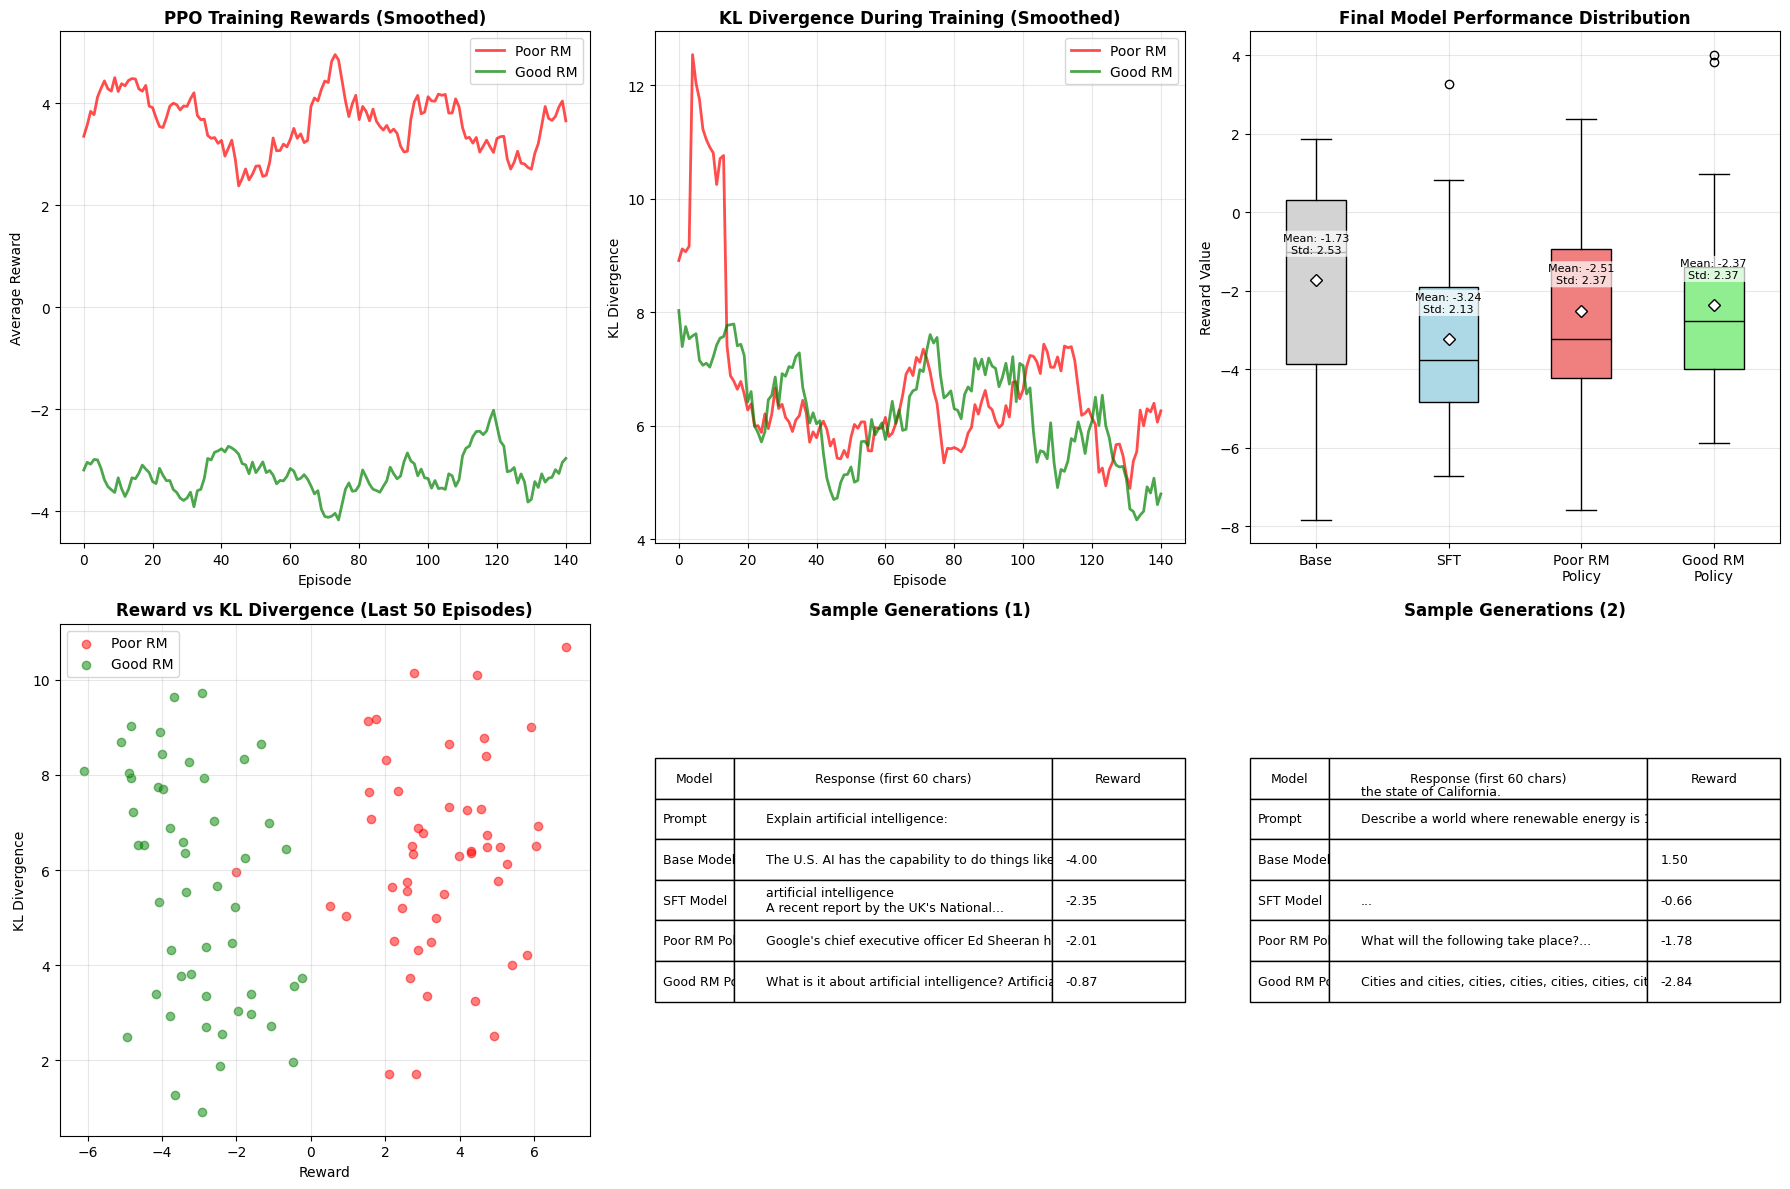

In [ ]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Training rewards comparison (with smoothing)
window = 10
def smooth(data, window_size=window):
    if len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

if len(poor_rewards) > window:
    smooth_poor = smooth(poor_rewards)
    smooth_good = smooth(good_rewards)

    axes[0, 0].plot(smooth_poor, label='Poor RM', color='red', alpha=0.7, linewidth=2)
    axes[0, 0].plot(smooth_good, label='Good RM', color='green', alpha=0.7, linewidth=2)
    axes[0, 0].set_title('PPO Training Rewards (Smoothed)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Episode')
    axes[0, 0].set_ylabel('Average Reward')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# 2. KL divergence during training
if len(poor_kls) > window:
    smooth_poor_kl = smooth(poor_kls)
    smooth_good_kl = smooth(good_kls)

    axes[0, 1].plot(smooth_poor_kl, label='Poor RM', color='red', alpha=0.7, linewidth=2)
    axes[0, 1].plot(smooth_good_kl, label='Good RM', color='green', alpha=0.7, linewidth=2)
    axes[0, 1].set_title('KL Divergence During Training (Smoothed)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Episode')
    axes[0, 1].set_ylabel('KL Divergence')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# 3. Final performance comparison - using Box Plot
all_rewards_data = [base_all_rewards, sft_all_rewards, poor_all_rewards, good_all_rewards]
labels = ['Base', 'SFT', 'Poor RM\nPolicy', 'Good RM\nPolicy']

# Create box plot
bp = axes[0, 2].boxplot(all_rewards_data, patch_artist=True, tick_labels=labels,
                    medianprops=dict(color='black'),
                    showmeans=True, meanprops=dict(marker='D', markeredgecolor='black',
                                                    markerfacecolor='white', markersize=6))

# Color the boxes (optional, for better visual distinction)
colors = ['lightgray', 'lightblue', 'lightcoral', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[0, 2].set_title('Final Model Performance Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Reward Value')
axes[0, 2].grid(True, alpha=0.3)

# Add mean and std annotations
for i, data_series in enumerate(all_rewards_data):
    mean_val = np.mean(data_series)
    std_val = np.std(data_series)
    x_pos_box = i + 1 # boxplot x positions are 1-indexed

    # Get the y-coordinate of the mean marker
    mean_y_coord = bp['means'][i].get_ydata()[0]

    # Calculate a dynamic offset based on the y-range of the current subplot
    ymin, ymax = axes[0, 2].get_ylim()
    y_range = ymax - ymin
    offset = y_range * 0.05 # 5% of the y-range as offset

    # Place text slightly above the mean marker
    va = 'bottom' # align text bottom to the point, so it draws upwards

    axes[0, 2].text(x_pos_box, mean_y_coord + offset,
                 f'Mean: {mean_val:.2f}\nStd: {std_val:.2f}',
                 horizontalalignment='center', verticalalignment=va,
                 fontsize=8, color='black',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

# 4. Reward vs KL scatter plot (last 50 episodes)
if len(poor_rewards) > 50 and len(poor_kls) > 50:
    last_episodes = 50
    poor_last_rewards = poor_rewards[-last_episodes:]
    poor_last_kls = poor_kls[-last_episodes:]
    good_last_rewards = good_rewards[-last_episodes:]
    good_last_kls = good_kls[-last_episodes:]

    axes[1, 0].scatter(poor_last_rewards, poor_last_kls, alpha=0.5, label='Poor RM', color='red')
    axes[1, 0].scatter(good_last_rewards, good_last_kls, alpha=0.5, label='Good RM', color='green')
    axes[1, 0].set_title('Reward vs KL Divergence (Last 50 Episodes)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Reward')
    axes[1, 0].set_ylabel('KL Divergence')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# 5. Sample responses table (First Sample)
axes[1, 1].axis('tight')
axes[1, 1].axis('off')

test_prompt = "Explain artificial intelligence:"

def get_response(model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_len = inputs['input_ids'].shape[-1] # Length of the input prompt in tokens

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=128, # Increased max_new_tokens
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.pad_token_id
        )

    # Decode only the newly generated tokens
    generated_tokens_ids = output[0, input_len:]
    response_text = tokenizer.decode(generated_tokens_ids, skip_special_tokens=True).strip()

    return response_text, output # Return generated text and full output IDs for reward calculation

# Get responses and their rewards for the table (First Sample)
base_response_text, base_output = get_response(base_model, test_prompt)
sft_response_text, sft_output = get_response(sft_model_eval, test_prompt)
poor_rm_response_text, poor_rm_output = get_response(ppo_poor.policy, test_prompt)
good_rm_response_text, good_rm_output = get_response(ppo_good.policy, test_prompt)

# Calculate rewards (First Sample)
with torch.no_grad():
    base_reward_sample = good_rm(base_output, torch.ones_like(base_output)).mean().item()
    sft_reward_sample = good_rm(sft_output, torch.ones_like(sft_output)).mean().item()
    poor_rm_reward_sample = good_rm(poor_rm_output, torch.ones_like(poor_rm_output)).mean().item()
    good_rm_reward_sample = good_rm(good_rm_output, torch.ones_like(good_rm_output)).mean().item()

table_data = [
    ["Prompt", test_prompt, ""],
    ["Base Model", base_response_text[:60] + "...", f"{base_reward_sample:.2f}"],
    ["SFT Model", sft_response_text[:60] + "...", f"{sft_reward_sample:.2f}"],
    ["Poor RM Policy", poor_rm_response_text[:60] + "...", f"{poor_rm_reward_sample:.2f}"],
    ["Good RM Policy", good_rm_response_text[:60] + "...", f"{good_rm_reward_sample:.2f}"]
]

table = axes[1, 1].table(cellText=table_data,
                      colLabels=['Model', 'Response (first 60 chars)', 'Reward'], # Added 'Reward' column
                      cellLoc='left',
                      loc='center',
                      colWidths=[0.15, 0.60, 0.25]) # Adjusted column widths
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
axes[1, 1].set_title('Sample Generations (1)', fontsize=12, fontweight='bold')


# 6. Sample responses table (Second Sample)
axes[1, 2].axis('tight')
axes[1, 2].axis('off')

test_prompt_2 = "Describe a world where renewable energy is 100% adopted:"

# Get responses and their rewards for the table (Second Sample)
bas_response_text_2, base_output_2 = get_response(base_model, test_prompt_2)
sft_response_text_2, sft_output_2 = get_response(sft_model_eval, test_prompt_2)
poor_rm_response_2, poor_rm_output_2 = get_response(ppo_poor.policy, test_prompt_2) # Correct variable name
good_rm_response_2, good_rm_output_2 = get_response(ppo_good.policy, test_prompt_2) # Correct variable name

# Calculate rewards (Second Sample)
with torch.no_grad():
    base_reward_sample_2 = good_rm(base_output_2, torch.ones_like(base_output_2)).mean().item()
    sft_reward_sample_2 = good_rm(sft_output_2, torch.ones_like(sft_output_2)).mean().item()
    poor_rm_reward_sample_2 = good_rm(poor_rm_output_2, torch.ones_like(poor_rm_output_2)).mean().item()
    good_rm_reward_sample_2 = good_rm(good_rm_output_2, torch.ones_like(good_rm_output_2)).mean().item()

table_data_2 = [
    ["Prompt", test_prompt_2, ""],
    ["Base Model", bas_response_text_2[:60] + "...", f"{base_reward_sample_2:.2f}"],
    ["SFT Model", sft_response_text_2[:60] + "...", f"{sft_reward_sample_2:.2f}"],
    ["Poor RM Policy", poor_rm_response_2[:60] + "...", f"{poor_rm_reward_sample_2:.2f}"], # Use corrected variable
    ["Good RM Policy", good_rm_response_2[:60] + "...", f"{good_rm_reward_sample_2:.2f}"]  # Use corrected variable
]

table_2 = axes[1, 2].table(cellText=table_data_2,
                      colLabels=['Model', 'Response (first 60 chars)', 'Reward'],
                      cellLoc='left',
                      loc='center',
                      colWidths=[0.15, 0.60, 0.25])
table_2.auto_set_font_size(False)
table_2.set_fontsize(9)
table_2.scale(1, 2)
axes[1, 2].set_title('Sample Generations (2)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()